In [402]:
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_digits, fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import ssl

In [403]:
ssl._create_default_https_context = ssl._create_unverified_context

In [404]:
digits = fetch_openml('mnist_784')
print(f"{digits.data.shape} {digits.target.shape}")

(70000, 784) (70000,)


In [405]:
data = load_digits()

In [406]:
digits = data.data


In [407]:
data.target.astype(int)

array([0, 1, 2, ..., 8, 9, 8], shape=(1797,))

In [408]:
target = data.target.astype(int)

In [409]:
scaler = StandardScaler()
n_images = len(data.data)
data = data.data/data.data.max()

In [410]:
from sklearn.preprocessing import OneHotEncoder

In [411]:
target.reshape(-1,1).shape

(1797, 1)

In [412]:
enc = OneHotEncoder(sparse_output=False)

target = enc.fit_transform(target.reshape(-1,1))

In [413]:
X_train, X_test, y_train, y_test = train_test_split(
    data, target, test_size=0.3, shuffle=False
)

In [414]:

# y_train = np.expand_dims(y_train, axis=0)
# y_test = np.expand_dims(y_test, axis=0)



In [415]:
print(f"shape train {X_train.shape} shape test {X_test.shape} {y_train.shape} {y_test.shape}")

shape train (1257, 64) shape test (540, 64) (1257, 10) (540, 10)


In [416]:
def layer_size(X, y):
    print(f"{X.shape} {y.shape}")
    return X.shape[0], y.shape[0]
    

In [417]:
## Inicializamos los pesos

def initialize_parameters(n_h= 1, n_x = 2, n_y = 1, n_h_2=2):
    
    scale_factor = 0.001
    
    w_1 = np.random.randn(n_h, n_x) * np.sqrt(2 / n_x)
    b1 = np.zeros((n_h, 1)) 
    w_2 = np.random.randn(n_h_2, n_h) * np.sqrt(2/n_h)
    b2 = np.zeros((n_h_2, 1))

    w_3 =np.random.randn(n_y, n_h_2) * np.sqrt(1/ n_h_2)
    b3 = np.zeros((n_y, 1))

    parameters = {"w1": w_1,
                  "b1": b1,
                  "w2": w_2,
                  "b2": b2,
                  "w3": w_3,
                  "b3": b3}
    
    return parameters

### Tendremos una entrada de dos neuronas, una capa oculta de 4 y una salidad de 1 neurona

# Definimos nuestra función de activación

In [418]:
def sigmoid(x):
    return 1/(1+np.exp(-x))

def relu(x):
    return np.maximum(0, x)

def softmax(Z):
    Z_shift = Z - np.max(Z, axis=0, keepdims=True)  # evita overflow
    expZ = np.exp(Z_shift)
    return expZ / np.sum(expZ, axis=0, keepdims=True)


### Forward propagation

In [419]:
def forward(X, parameters):
    w_1 = parameters.get("w1")
    b1 = parameters.get("b1")
    w_2 = parameters.get("w2")
    b2 = parameters.get("b2")
    w_3 = parameters.get("w3")
    b3 = parameters.get("b3")

    Z1 = np.dot(w_1, X) + b1 
    A1 = relu(Z1) 
    Z2 = np.dot(w_2, A1) + b2
    A2 = relu(Z2)
    Z3 = np.dot(w_3, A2) + b3
    A3 = softmax(Z3)


    return Z1, A1, Z2, A2, Z3, A3

In [420]:
def cost(A2, Y):##
    m = Y.shape[1]
    # logprobs =   np.multiply(np.log(A2),Y)+np.multiply((1-Y),np.log(1-A2)) 
    cost = - np.sum(Y * np.log(A2))/m
    cost = float(np.squeeze(cost))
    return cost

In [ ]:
def backward_propagation(w1, w2, w3, b1, b2, b3, A1,A2, A3, X,Y, z1, z2): 
    m = X.shape[1]
    dZ3 = A3 - Y
    dw3 = (1/m) * np.dot(dZ3, A2.T)
    db3 = (1/m) * np.sum(dZ3, axis=1, keepdims=True)
    dZ2 = np.dot(w3.T, dZ3)
    dZ2[z2 <= 0] = 0
    dW2 = (1/m) * np.dot(dZ2, A1.T)
    db2 = (1/m) * np.sum(dZ2, axis=1, keepdims=True)
    dZ1 = (np.dot(w2.T, dZ2))#  1 - np.power(A1, 2)
    dZ1[z1 <= 0] = 0
    dW1 = (1/m) * np.dot(dZ1, X.T)
    db1 = (1/m) * np.sum(dZ1, axis=1, keepdims=True)

    grads = {
        "dw1": dW1, "dw2": dW2, "dw3": dw3, "db1": db1, "db2": db2, "db3": db3
    }
    return grads


In [422]:
def update_parameters(w1, w2, w3, b1, b2, b3, grads, learning_rate):

    dW1 = grads.get("dw1") 
    dW2 = grads.get("dw2") 
    db1 = grads.get("db1") 
    db2 = grads.get("db2") 
    dW3 = grads.get("dw3")
    db3 = grads.get("db3")

    w1 -= learning_rate*dW1
    w2 -= learning_rate*dW2
    b1 -= learning_rate*db1
    b2 -= learning_rate*db2
    w3 -= learning_rate*dW3
    b3 -= learning_rate*db3

    return {"w1":w1, "w2":w2, "w3": w3, "b1":b1, "b2":b2, "b3":b3}

In [423]:
def predict(parameters, X):
    _,_,_,_,_,A3 = forward(X,parameters)
    return np.argmax(A3, axis=0) 



In [424]:
def neural_network(X,Y, n_h, n_h2, learning_rate, num_iterations=500, print_cost=False, debug=False):
    n_x, n_y= layer_size(X, Y)
    print(f"{n_x} --- {n_y}")
    # Initializing parameters 
    parameters = initialize_parameters(n_h, n_x, n_y, n_h2)

    w1 = parameters.get("w1")
    b1 = parameters.get("b1")
    w2 = parameters.get("w2")
    b2 = parameters.get("b2")
    w3 = parameters.get("w3")
    b3 = parameters.get("b3")



    for i in range(0,num_iterations):
        ## Forward propagation
        Z1, A1, Z2, A2, Z3, A3 = forward(X, parameters)
        # Backward propagation
        grads = backward_propagation(w1, w2,w3,b1,b2,b3,A1,A2,A3,X,Y,Z1,Z2)
        ## Updating parameters
        updated_parameters = update_parameters(w1,w2, w3,b1,b2, b3, grads, learning_rate)
        ## Obtaining parameters
        w1 = updated_parameters.get("w1")
        w2 = updated_parameters.get("w2")
        w3 = updated_parameters.get("w3")
        b1 = updated_parameters.get("b1")
        b2 = updated_parameters.get("b2")
        b3 = updated_parameters.get("b3")

        if print_cost and i % 1000 == 0:
            y_pred = predict(updated_parameters, X)
            y_true = np.argmax(Y, axis=0)
            print(f"Accuracy on iteration{i}: {accuracy_score(y_true, y_pred)}")

        if debug and i % 1000 == 0:
                # Debugging prints: rangos y normas de gradientes
                print("DEBUG iter", i, "Z2 min/max:", np.min(Z2), np.max(Z2))
                print("A2 min/max:", np.min(A2), np.max(A2))
                # grad norms
                print("||dW1||, ||dW2||:", np.linalg.norm(grads.get("dw1") ), np.linalg.norm(grads.get("dw2")))
                print("-"*12)
    return updated_parameters
    




In [425]:
parameters = neural_network(X_train.T, y_train.T, 64, 20 ,5e-2,num_iterations=4000,print_cost=True, debug=True)


(64, 1257) (10, 1257)
64 --- 10
Accuracy on iteration0: 0.147175815433572
DEBUG iter 0 Z2 min/max: -2.2829783925084826 2.2481513146665346
A2 min/max: 0.0 2.2481513146665346
||dW1||, ||dW2||: 0.46595486833804706 0.44241089565545727
------------


Accuracy on iteration1000: 0.9864757358790772
DEBUG iter 1000 Z2 min/max: -4.945685004737636 9.862824113591998
A2 min/max: 0.0 9.862824113591998
||dW1||, ||dW2||: 0.02553485902267509 0.018650768134605887
------------
Accuracy on iteration2000: 0.9960222752585521
DEBUG iter 2000 Z2 min/max: -5.090280226814376 11.308238150855837
A2 min/max: 0.0 11.308238150855837
||dW1||, ||dW2||: 0.013466366939960244 0.009884468855299198
------------
Accuracy on iteration3000: 0.9984089101034208
DEBUG iter 3000 Z2 min/max: -5.1914084096245965 12.245271541096892
A2 min/max: 0.0 12.245271541096892
||dW1||, ||dW2||: 0.00870939305977815 0.0063125136128899155
------------


In [426]:
predictions = predict(parameters, X_test.T)

In [427]:
predictions.shape

(540,)

In [428]:
y_test = enc.inverse_transform(y_test)

In [429]:
print ("Accuray", accuracy_score(y_test, predictions)*100)

Accuray 92.77777777777779


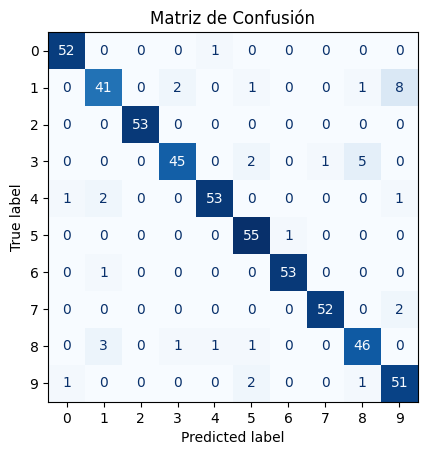

In [430]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', colorbar=False)
plt.title("Matriz de Confusión")
plt.show()
